In [4]:
import pandas as pd
import seaborn as sns

In [7]:
df = pd.read_csv("Superstore.csv",encoding="latin1")

In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.shape

(9994, 21)

In [10]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [11]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [19]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors='coerce')
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True, errors='coerce')

print(df["Order Date"].head())
print(df["Order Date"].dtype)
print(df["Ship Date"].dtype)

0   2013-11-09
1   2013-11-09
2   2013-06-13
3   2012-10-11
4   2012-10-11
Name: Order Date, dtype: datetime64[ns]
datetime64[ns]
datetime64[ns]


In [22]:
df["Month"] = df["Order Date"].dt.to_period("M")
df["Year"] = df["Order Date"].dt.year
print(df[["Order Date", "Month", "Year"]].head())

  Order Date    Month  Year
0 2013-11-09  2013-11  2013
1 2013-11-09  2013-11  2013
2 2013-06-13  2013-06  2013
3 2012-10-11  2012-10  2012
4 2012-10-11  2012-10  2012


In [12]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [14]:
 df.median(numeric_only=True)

Row ID          4997.5000
Postal Code    56430.5000
Sales             54.4900
Quantity           3.0000
Discount           0.2000
Profit             8.6665
dtype: float64

In [15]:
df.mode(numeric_only=True).iloc[0]

Row ID             1.00
Postal Code    10035.00
Sales             12.96
Quantity           3.00
Discount           0.00
Profit             0.00
Name: 0, dtype: float64

Month
2011-01    13946.229
2011-02     4810.558
2011-03    55691.009
2011-04    28295.345
2011-05    23648.287
Freq: M, Name: Sales, dtype: float64


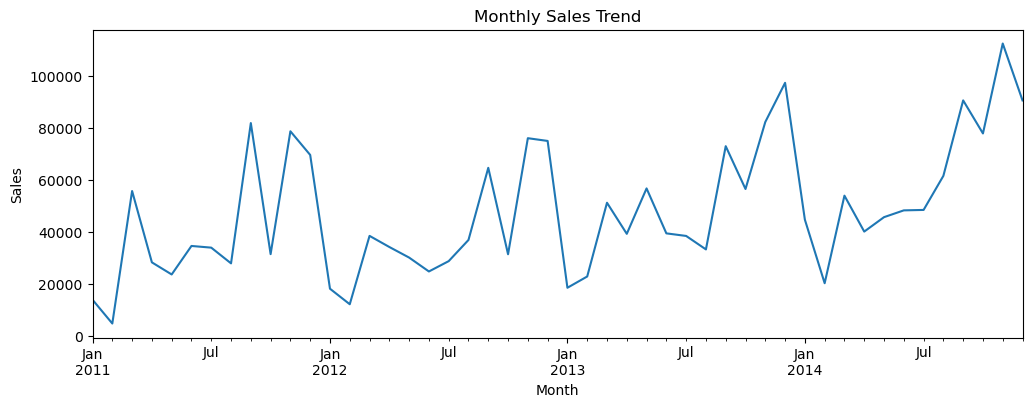

In [25]:
monthly_sales = df.groupby("Month")["Sales"].sum()
print(monthly_sales.head())
import matplotlib.pyplot as plt 
monthly_sales.plot(figsize=(12,4))
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()
                   

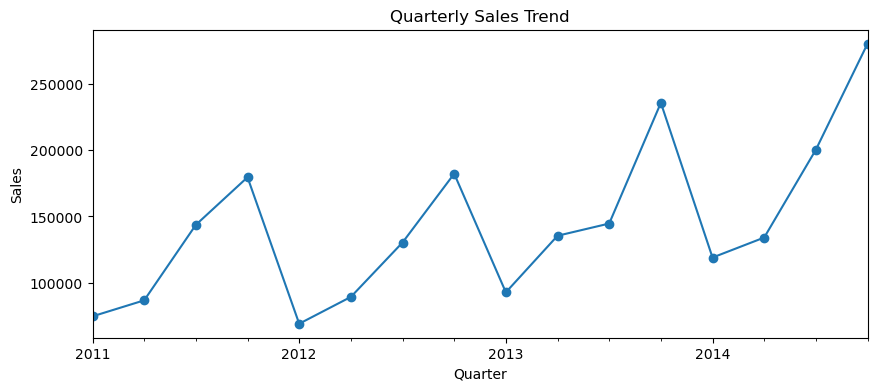

Quarter
2011Q1     74447.7960
2011Q2     86538.7596
2011Q3    143633.2123
2011Q4    179627.7302
2012Q1     68851.7386
2012Q2     89124.1870
2012Q3    130259.5752
2012Q4    182297.0082
2013Q1     92596.4190
2013Q2    135370.1130
2013Q3    144614.4282
2013Q4    235892.8698
2014Q1    118895.6174
2014Q2    134023.4058
2014Q3    200433.1730
2014Q4    280594.8270
Freq: Q-DEC, Name: Sales, dtype: float64


In [28]:
df["Quarter"] = df["Order Date"].dt.to_period("Q")
quarterly_sales = df.groupby("Quarter")["Sales"].sum()

quarterly_sales.plot(kind='line', marker='o', figsize=(10,4))
plt.title("Quarterly Sales Trend")
plt.ylabel("Sales")
plt.show()

print(quarterly_sales)

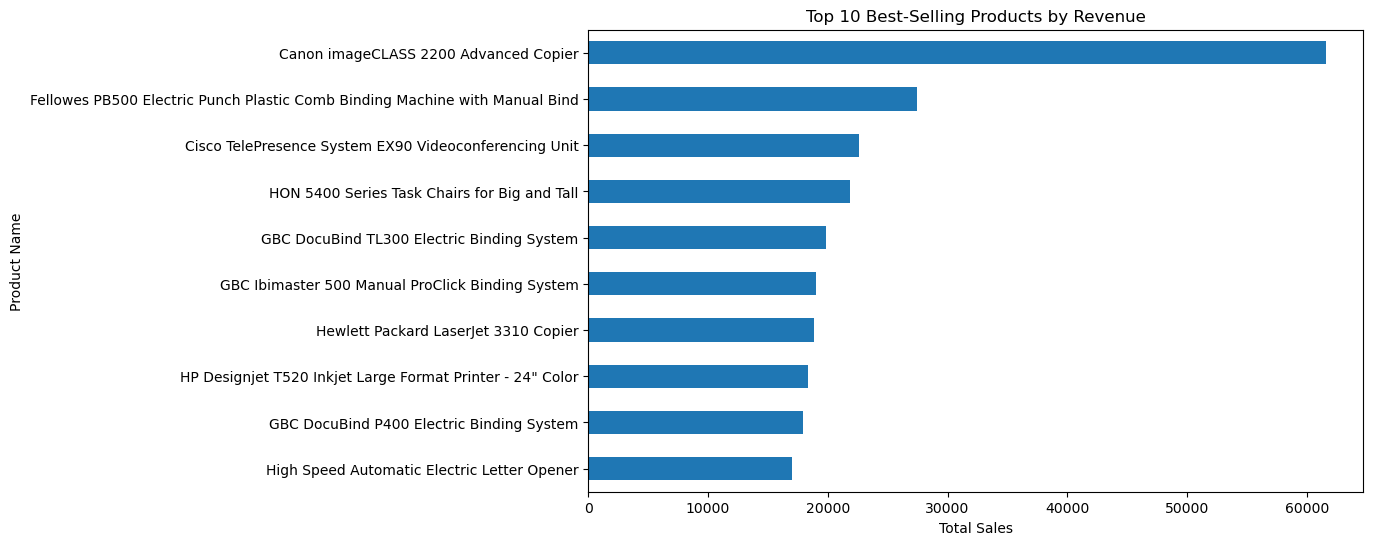

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [29]:
top10 = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top10.plot(kind='barh', figsize=(10,6))
plt.title("Top 10 Best-Selling Products by Revenue")
plt.xlabel("Total Sales")
plt.gca().invert_yaxis()
plt.show()
print(top10)

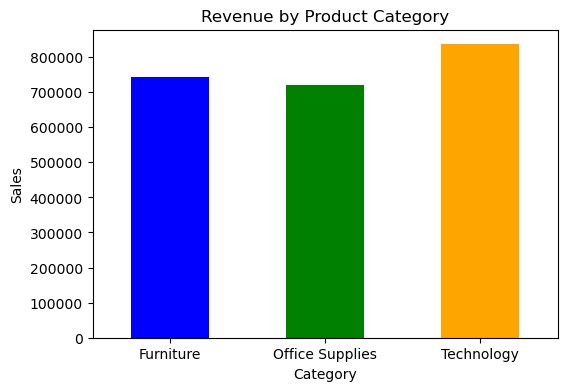

In [32]:
df.groupby("Category")["Sales"].sum().plot(kind='bar', figsize=(6,4), color=['blue', 'green', 'orange'])
plt.title("Revenue by Product Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [33]:
import seaborn as sns 

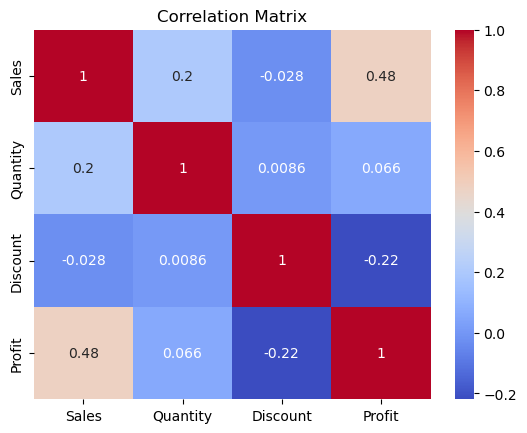

In [43]:
import seaborn as sns 
sns.heatmap(df[["Sales", "Quantity", "Discount","Profit"]].corr(), annot=True, cmap= 'coolwarm')
plt.title("Correlation Matrix")
plt.show()

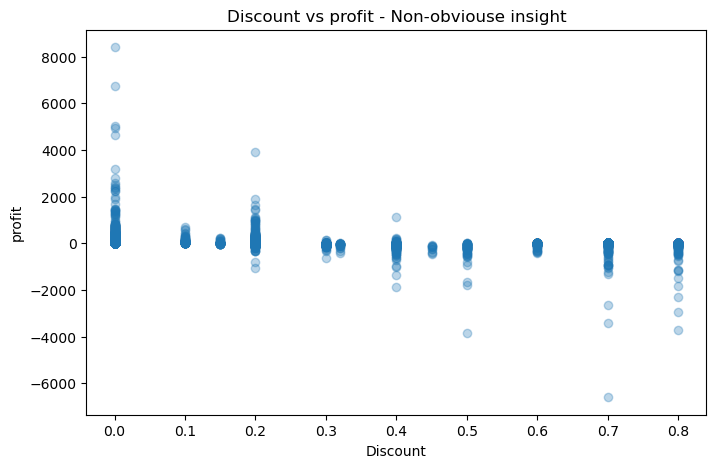

In [40]:
plt.figure(figsize=(8,5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.3)
plt.title("Discount vs profit - Non-obviouse insight")
plt.xlabel("Discount")
plt.ylabel("profit")
plt.show()

  
CONCLUSION :
Based on the Superstore analysis:

1. **Focuse on Tecnology category** - it generates the highest revenue (~836k USD). Invest more in Technology products.

2. **Control Discounts** -Correlation shows Discount vs Profit is -0.22. Stop giving 40-80% Scatter plot proves profit becomes negative (-3000 to -6000) at high discounts.

3. **Plan for Q4** - Time series shows Q4 peak sales every year (2011 Q4: ~185k, 2014 Q4: ~300k). Stock invetory in September for November-December rush.

4. **Note on Demographics** - Dataset has no Age/Gender column, so Customer Segment analysis was used instead. Consumer Segment is highest sales(~51% of total)      
        


   
  Report:
1  Quarterly sales show an upward trend from 2011 to 2014.
   Sales peak in Q4 every where (holidays season)-2011 Q4-185k, 2013 Q3 -250k,2014 Q4~300k.
2  Sales vs Profit= 0.48 (moderate positive hiher sales brings more profit)
3  Discount vs Profit = -0.22(negative- givig more discount vs reduce  Profit)
4  Quantity vs Profit = 0.066(almost no relation) Discount ), profit goes negative (-3000)

  Key Correlations: Sales-Profit = 0.48(positive),
  Discount-profit = -0.22 (negative),
  Quantity-Profit = 0.66 ( no correlation)



Sales vs Profit= 0.48(Moderate Positive). While higher sales drive profit, the correlation is not  strong because  excessive discounts (40-80%) cause highe-value sales to result in losses. To make sales truly profitable, discount must be controlled.  




In [6]:
df.shape

(9994, 21)

In [7]:
df.groupby('Category')['Sales'].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64